# Liver Cirrhosis Stage Classification Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Preprocessing, and Feature Engineering

In [ ]:
liver = pd.read_csv('/content/liver_cirrhosis.csv')
liver.head(10)

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.000000,4.04,227.0,598.0,52.70,57.000000,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.000000,3.93,22.0,663.0,45.00,75.000000,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.000000,3.54,51.0,1243.0,122.45,80.000000,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.000000,3.74,23.0,1024.0,77.50,58.000000,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.000000,3.54,74.0,1052.0,108.50,109.000000,151.0,11.5,1
5,4427,C,Placebo,16418,F,N,N,N,N,1.9,259.000000,3.70,281.0,10396.8,188.34,178.000000,327.0,10.4,2
6,1418,C,Placebo,23011,F,Y,N,Y,N,1.3,291.000000,3.44,75.0,1082.0,85.00,195.000000,156.0,10.3,2
7,51,D,Placebo,24107,F,Y,N,Y,Y,12.6,200.000000,2.74,140.0,918.0,147.25,143.000000,150.0,11.1,3
8,2504,C,Placebo,15265,F,N,N,N,N,2.3,369.510563,3.93,24.0,1828.0,133.30,124.702128,474.0,10.9,1
9,1012,D,Placebo,22280,M,Y,N,Y,S,1.4,176.000000,3.48,210.0,516.0,96.10,55.000000,259.0,10.1,3


In [ ]:
liver.tail(10)

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
24990,1690,D,D-penicillamine,17512,F,N,Y,N,N,6.3,436.000000,3.02,75.000000,2176.000000,170.500000,104.000000,236.0,10.6,3
24991,4365,C,D-penicillamine,21324,F,N,N,N,N,0.9,346.000000,3.40,81.000000,1098.000000,122.450000,90.000000,228.0,10.3,2
24992,694,D,D-penicillamine,28650,M,Y,Y,Y,N,0.8,300.000000,2.94,231.000000,1794.000000,130.200000,99.000000,97.0,11.2,3
24993,2475,CL,D-penicillamine,13329,F,N,N,N,N,3.4,450.000000,3.37,32.000000,1408.000000,116.250000,118.000000,313.0,11.2,1
24994,1654,C,Placebo,19724,M,Y,N,Y,N,1.7,369.510563,2.38,97.648387,1982.655769,122.556346,124.702128,166.0,9.8,2
24995,3584,D,D-penicillamine,23612,F,N,N,N,N,0.8,231.000000,3.87,173.000000,9009.800000,127.710000,96.000000,295.0,11.0,2
24996,3584,D,D-penicillamine,23612,F,N,N,N,N,0.8,231.000000,3.87,173.000000,9009.800000,127.710000,96.000000,295.0,11.0,2
24997,971,D,D-penicillamine,16736,F,N,Y,Y,Y,5.1,369.510563,3.23,18.000000,790.000000,179.800000,124.702128,104.0,13.0,3
24998,3707,C,D-penicillamine,16990,F,N,Y,N,N,0.8,315.000000,4.24,13.000000,1637.000000,170.500000,70.000000,426.0,10.9,2
24999,3707,C,D-penicillamine,16990,F,N,Y,N,N,0.8,315.000000,4.24,13.000000,1637.000000,170.500000,70.000000,426.0,10.9,2


In [ ]:
liver.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,1887.117040,18495.877080,3.402644,372.331471,3.486578,100.184663,1995.675597,123.166345,123.822548,256.007337,10.734549,2.00116
std,1091.690918,3737.596616,4.707491,193.668452,0.380488,73.184840,1798.885660,47.747616,52.786350,98.679006,0.904436,0.81387
min,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.00000
25%,1080.000000,15694.000000,0.800000,275.000000,3.290000,52.000000,1032.000000,92.000000,92.000000,189.000000,10.000000,1.00000
50%,1680.000000,18499.000000,1.300000,369.510563,3.510000,97.648387,1828.000000,122.556346,124.702128,251.000000,10.600000,2.00000
75%,2576.000000,20955.000000,3.400000,369.510563,3.750000,107.000000,1982.655769,134.850000,127.000000,311.000000,11.100000,3.00000
max,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,3.00000


In [ ]:
liver.shape

(25000, 19)

In [ ]:
liver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

In [ ]:
liver.isnull().sum()

,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


In [ ]:
# output feature distribution check

output_feature_distribution = liver['Stage'].value_counts()
output_feature_distribution

,count
Stage,
2,8441
3,8294
1,8265


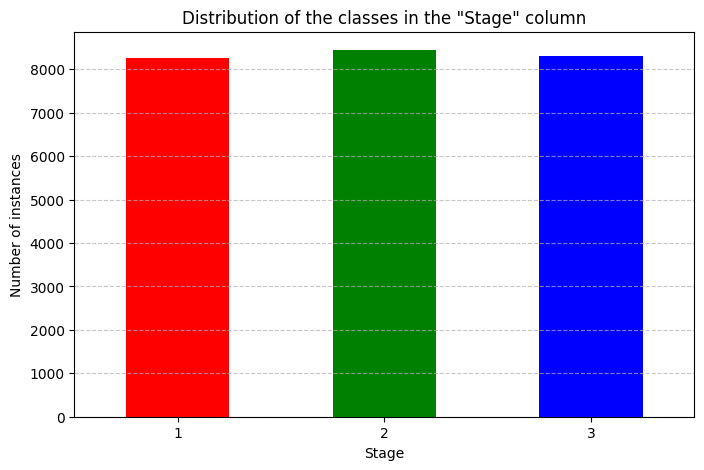

In [ ]:
plt.figure(figsize=(8, 5))
output_feature_distribution.sort_index().plot(kind='bar', color=['red', 'green', 'blue'])

plt.title('Distribution of the classes in the "Stage" column')
plt.xlabel('Stage')
plt.ylabel('Number of instances')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

# Categorical Data

liver.select_dtypes(include=['object', 'category']).columns

Index(['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object')

In [ ]:
# Numerical Data

liver.select_dtypes(include=['int64', 'float64']).columns

Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')

In [ ]:
# check duplicate

print("Duplicate data present:",liver.duplicated().sum())

Duplicate data present: 15361


In [ ]:
# Drop the duplicate rows

liver.drop_duplicates(inplace=True)

print(f"After dropping duplicate rows, duplicate rows: {liver.duplicated().sum()}")

After dropping duplicate rows, duplicate rows: 0


In [ ]:
liver.shape

(9639, 19)

In [ ]:
# Label encoder

from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()

selected_column = ['Sex', 'Ascites', 'Hepatomegaly', 'Spiders']
enc_column = ['Sex_enc', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc']

for i in range(len(selected_column)):
  liver[enc_column[i]] = enc.fit_transform(liver[selected_column[i]])

In [ ]:
# one hot encoder

enc_cat = pd.get_dummies(liver, columns=['Status', 'Drug', 'Edema'])
enc_cat.head(10)

,N_Days,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,Albumin,Copper,...,Hepatomegaly_enc,Spiders_enc,Status_C,Status_CL,Status_D,Drug_D-penicillamine,Drug_Placebo,Edema_N,Edema_S,Edema_Y
0,2221,18499,F,N,Y,N,0.5,149.000000,4.04,227.0,...,1,0,True,False,False,False,True,True,False,False
1,1230,19724,M,Y,N,Y,0.5,219.000000,3.93,22.0,...,0,1,True,False,False,False,True,True,False,False
2,4184,11839,F,N,N,N,0.5,320.000000,3.54,51.0,...,0,0,True,False,False,False,True,True,False,False
3,2090,16467,F,N,N,N,0.7,255.000000,3.74,23.0,...,0,0,False,False,True,False,True,True,False,False
4,2105,21699,F,N,Y,N,1.9,486.000000,3.54,74.0,...,1,0,False,False,True,False,True,True,False,False
5,4427,16418,F,N,N,N,1.9,259.000000,3.70,281.0,...,0,0,True,False,False,False,True,True,False,False
6,1418,23011,F,Y,N,Y,1.3,291.000000,3.44,75.0,...,0,1,True,False,False,False,True,True,False,False
7,51,24107,F,Y,N,Y,12.6,200.000000,2.74,140.0,...,0,1,False,False,True,False,True,False,False,True
8,2504,15265,F,N,N,N,2.3,369.510563,3.93,24.0,...,0,0,True,False,False,False,True,True,False,False
9,1012,22280,M,Y,N,Y,1.4,176.000000,3.48,210.0,...,0,1,False,False,True,False,True,False,True,False


In [ ]:
select_columns = ['Status_C', 'Status_CL', 'Status_D', 'Drug_D-penicillamine', 'Drug_Placebo', 'Edema_N', 'Edema_S', 'Edema_Y']
enc_columns = ['Status_C_enc', 'Status_CL_enc', 'Status_D_enc', 'Drug_D-penicillamine_enc', 'Drug_Placebo_enc', 'Edema_N_enc', 'Edema_S_enc', 'Edema_Y_enc']
for i in range(len(select_columns)):
  enc_cat[enc_columns[i]] = enc.fit_transform(enc_cat[select_columns[i]])

In [ ]:
df = enc_cat.select_dtypes(include=['int64', 'float64'])
df.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,...,Hepatomegaly_enc,Spiders_enc,Status_C_enc,Status_CL_enc,Status_D_enc,Drug_D-penicillamine_enc,Drug_Placebo_enc,Edema_N_enc,Edema_S_enc,Edema_Y_enc
0,2221,18499,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,...,1,0,1,0,0,0,1,1,0,0
1,1230,19724,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,...,0,1,1,0,0,0,1,1,0,0
2,4184,11839,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,...,0,0,1,0,0,0,1,1,0,0
3,2090,16467,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,...,0,0,0,0,1,0,1,1,0,0
4,2105,21699,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,...,1,0,0,0,1,0,1,1,0,0


In [ ]:
df.corr()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,...,Hepatomegaly_enc,Spiders_enc,Status_C_enc,Status_CL_enc,Status_D_enc,Drug_D-penicillamine_enc,Drug_Placebo_enc,Edema_N_enc,Edema_S_enc,Edema_Y_enc
N_Days,1.000000,-0.040165,-0.360085,-0.128472,0.356724,-0.282175,0.103293,-0.172858,-0.122437,0.076910,...,-0.129017,-0.143711,0.386934,-0.100030,-0.345492,0.041031,-0.041031,0.243574,-0.167711,-0.181964
Age,-0.040165,1.000000,0.033129,-0.016633,-0.079473,0.023270,0.019819,-0.004338,0.025022,-0.110962,...,0.004142,0.055100,-0.050987,-0.056902,0.080577,-0.009087,0.009087,-0.074257,0.052235,0.053522
Bilirubin,-0.360085,0.033129,1.000000,0.352128,-0.261289,0.415024,0.132452,0.352464,0.348441,-0.057845,...,0.196907,0.083901,-0.404855,-0.003374,0.415527,-0.027573,0.027573,-0.224511,0.119361,0.229890
Cholesterol,-0.128472,-0.016633,0.352128,1.000000,-0.062745,0.145975,0.117639,0.322516,0.267370,0.021675,...,0.082141,0.011143,-0.165716,0.024604,0.157089,0.007699,-0.007699,0.024222,-0.013791,-0.023191
Albumin,0.356724,-0.079473,-0.261289,-0.062745,1.000000,-0.168684,-0.112579,-0.147288,-0.103002,0.107520,...,-0.134417,-0.146372,0.227018,0.013881,-0.238998,0.023666,-0.023666,0.224661,-0.106281,-0.253268
Copper,-0.282175,0.023270,0.415024,0.145975,-0.168684,1.000000,0.184010,0.285004,0.239718,-0.041501,...,0.125763,0.086817,-0.343449,0.073973,0.314074,-0.024401,0.024401,-0.139246,0.041210,0.200504
Alk_Phos,0.103293,0.019819,0.132452,0.117639,-0.112579,0.184010,1.000000,0.137406,0.153621,0.010308,...,0.069136,0.000705,-0.152667,-0.056367,0.184246,0.005690,-0.005690,-0.055542,0.035476,0.046378
SGOT,-0.172858,-0.004338,0.352464,0.322516,-0.147288,0.285004,0.137406,1.000000,0.118804,-0.036971,...,0.078962,0.055925,-0.246362,0.023991,0.239830,-0.014595,0.014595,-0.097149,0.049745,0.102836
Tryglicerides,-0.122437,0.025022,0.348441,0.267370,-0.103002,0.239718,0.153621,0.118804,1.000000,-0.009454,...,0.087224,0.038384,-0.178314,0.023454,0.170541,0.003876,-0.003876,-0.090511,0.089398,0.019828
Platelets,0.076910,-0.110962,-0.057845,0.021675,0.107520,-0.041501,0.010308,-0.036971,-0.009454,1.000000,...,-0.091019,-0.171224,0.039657,0.022938,-0.052009,0.056927,-0.056927,0.070207,-0.039291,-0.068420


<Axes: >

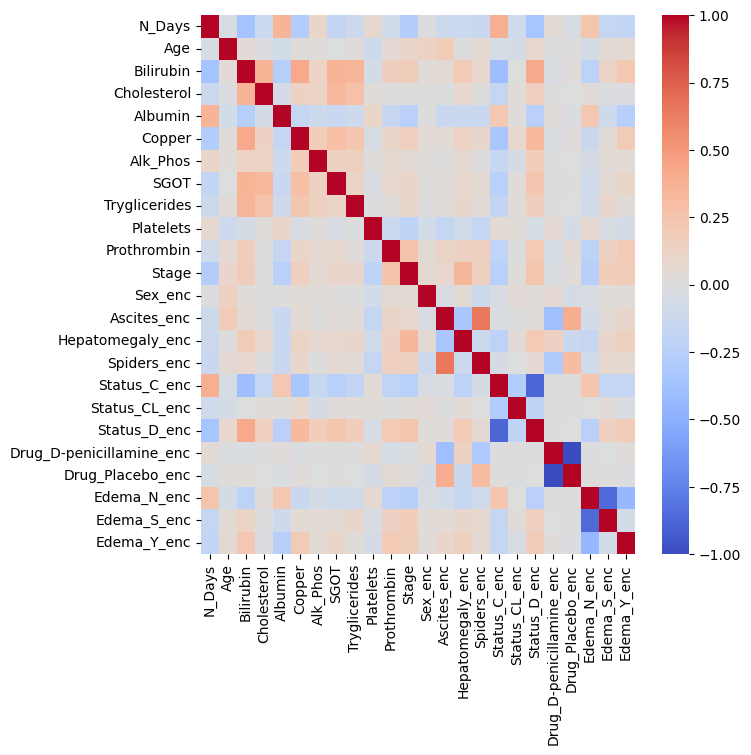

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 7))
sns.heatmap(df.corr(), cmap='coolwarm')

In [ ]:
# drop columns which has higher correlation

df.drop(columns=['Status_C_enc', 'Status_D_enc', 'Drug_D-penicillamine_enc', 'Drug_Placebo_enc', 'Edema_N_enc', 'Edema_S_enc'], axis=1, inplace=True)
df.shape

(9639, 18)

# Model Training and Testing

In [ ]:
X = df.drop(columns=['Stage'], axis=1)
y = df[['Stage']]

In [ ]:
X.columns

Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Sex_enc', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc',
       'Status_CL_enc', 'Edema_Y_enc'],
      dtype='object')

In [ ]:
Y=df['Stage']

In [ ]:
xtrain1=X.drop([ 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Sex_enc', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc',
       'Status_CL_enc', 'Edema_Y_enc'],axis=1)


array([[<Axes: xlabel='N_Days', ylabel='N_Days'>,
        <Axes: xlabel='Age', ylabel='N_Days'>,
        <Axes: xlabel='Bilirubin', ylabel='N_Days'>,
        <Axes: xlabel='Cholesterol', ylabel='N_Days'>],
       [<Axes: xlabel='N_Days', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Bilirubin', ylabel='Age'>,
        <Axes: xlabel='Cholesterol', ylabel='Age'>],
       [<Axes: xlabel='N_Days', ylabel='Bilirubin'>,
        <Axes: xlabel='Age', ylabel='Bilirubin'>,
        <Axes: xlabel='Bilirubin', ylabel='Bilirubin'>,
        <Axes: xlabel='Cholesterol', ylabel='Bilirubin'>],
       [<Axes: xlabel='N_Days', ylabel='Cholesterol'>,
        <Axes: xlabel='Age', ylabel='Cholesterol'>,
        <Axes: xlabel='Bilirubin', ylabel='Cholesterol'>,
        <Axes: xlabel='Cholesterol', ylabel='Cholesterol'>]], dtype=object)

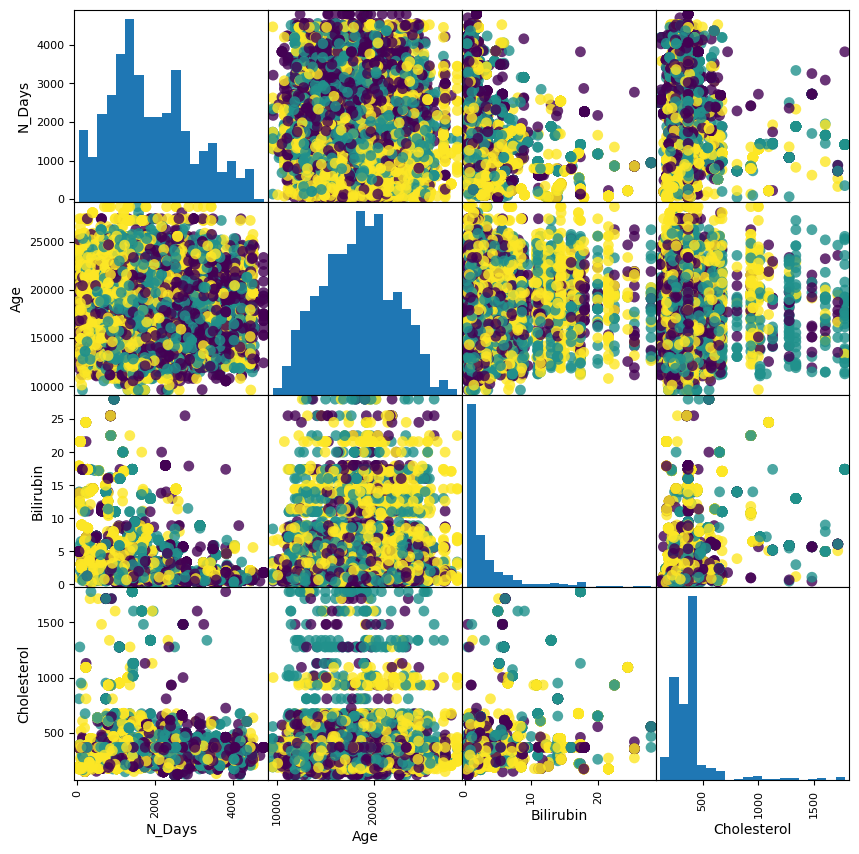

In [ ]:

liver_dataframe = pd.DataFrame(xtrain1, columns=xtrain1.columns)
pd.plotting.scatter_matrix(liver_dataframe, c=Y, figsize=(10, 10),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)


In [ ]:
xtrain2=X.drop(['N_Days', 'Age', 'Bilirubin', 'Cholesterol','Tryglicerides', 'Platelets', 'Prothrombin',
       'Sex_enc', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc',
       'Status_CL_enc', 'Edema_Y_enc' ],axis=1)

array([[<Axes: xlabel='Albumin', ylabel='Albumin'>,
        <Axes: xlabel='Copper', ylabel='Albumin'>,
        <Axes: xlabel='Alk_Phos', ylabel='Albumin'>,
        <Axes: xlabel='SGOT', ylabel='Albumin'>],
       [<Axes: xlabel='Albumin', ylabel='Copper'>,
        <Axes: xlabel='Copper', ylabel='Copper'>,
        <Axes: xlabel='Alk_Phos', ylabel='Copper'>,
        <Axes: xlabel='SGOT', ylabel='Copper'>],
       [<Axes: xlabel='Albumin', ylabel='Alk_Phos'>,
        <Axes: xlabel='Copper', ylabel='Alk_Phos'>,
        <Axes: xlabel='Alk_Phos', ylabel='Alk_Phos'>,
        <Axes: xlabel='SGOT', ylabel='Alk_Phos'>],
       [<Axes: xlabel='Albumin', ylabel='SGOT'>,
        <Axes: xlabel='Copper', ylabel='SGOT'>,
        <Axes: xlabel='Alk_Phos', ylabel='SGOT'>,
        <Axes: xlabel='SGOT', ylabel='SGOT'>]], dtype=object)

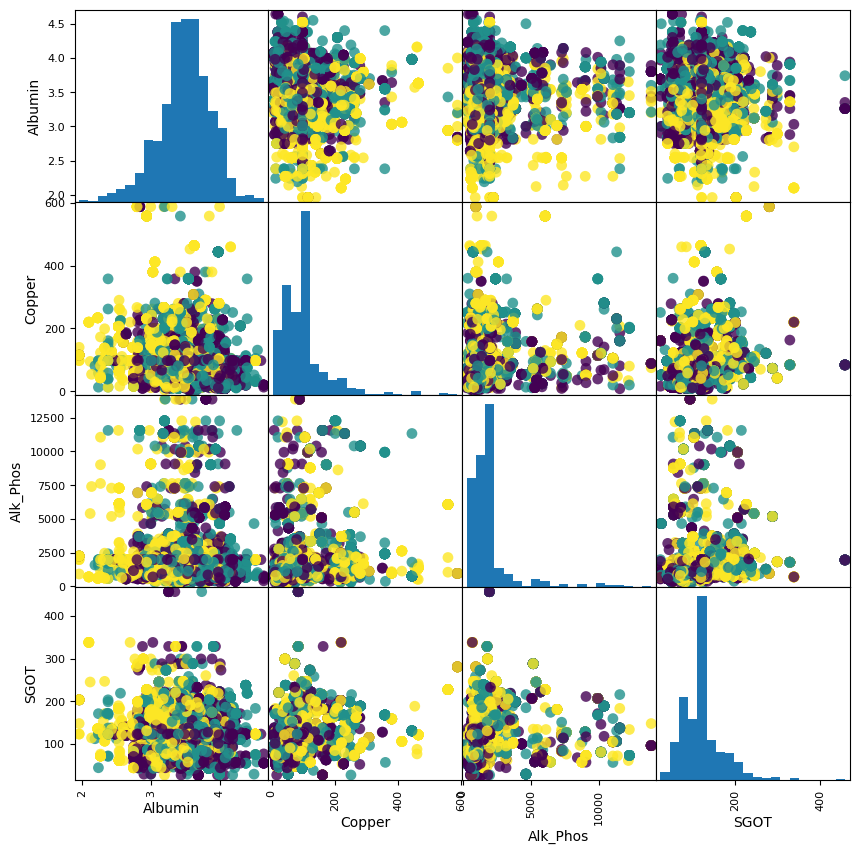

In [ ]:

liver_dataframe = pd.DataFrame(xtrain2, columns=xtrain2.columns)

pd.plotting.scatter_matrix(liver_dataframe, c=Y, figsize=(10, 10),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)


In [ ]:
xtrain3=X.drop(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc',
       'Status_CL_enc', 'Edema_Y_enc'],axis=1)

array([[<Axes: xlabel='Tryglicerides', ylabel='Tryglicerides'>,
        <Axes: xlabel='Platelets', ylabel='Tryglicerides'>,
        <Axes: xlabel='Prothrombin', ylabel='Tryglicerides'>,
        <Axes: xlabel='Sex_enc', ylabel='Tryglicerides'>],
       [<Axes: xlabel='Tryglicerides', ylabel='Platelets'>,
        <Axes: xlabel='Platelets', ylabel='Platelets'>,
        <Axes: xlabel='Prothrombin', ylabel='Platelets'>,
        <Axes: xlabel='Sex_enc', ylabel='Platelets'>],
       [<Axes: xlabel='Tryglicerides', ylabel='Prothrombin'>,
        <Axes: xlabel='Platelets', ylabel='Prothrombin'>,
        <Axes: xlabel='Prothrombin', ylabel='Prothrombin'>,
        <Axes: xlabel='Sex_enc', ylabel='Prothrombin'>],
       [<Axes: xlabel='Tryglicerides', ylabel='Sex_enc'>,
        <Axes: xlabel='Platelets', ylabel='Sex_enc'>,
        <Axes: xlabel='Prothrombin', ylabel='Sex_enc'>,
        <Axes: xlabel='Sex_enc', ylabel='Sex_enc'>]], dtype=object)

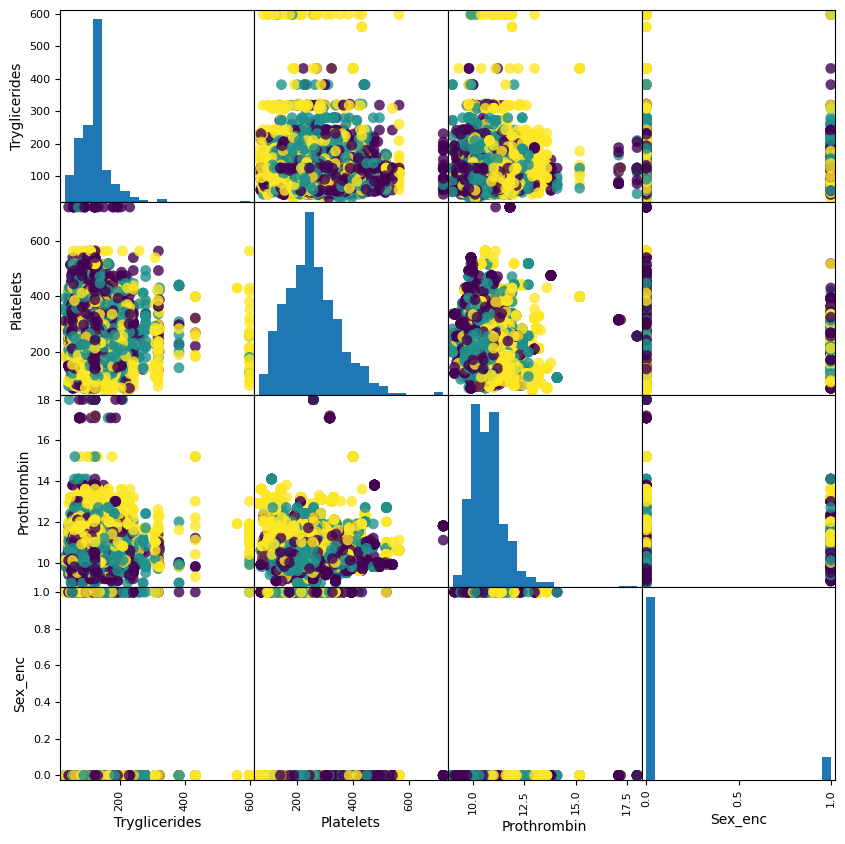

In [ ]:

liver_dataframe = pd.DataFrame(xtrain3, columns=xtrain3.columns)

pd.plotting.scatter_matrix(liver_dataframe, c=Y, figsize=(10, 10),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)


In [ ]:
xtrain4=X.drop(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Sex_enc'],axis=1)

array([[<Axes: xlabel='Ascites_enc', ylabel='Ascites_enc'>,
        <Axes: xlabel='Hepatomegaly_enc', ylabel='Ascites_enc'>,
        <Axes: xlabel='Spiders_enc', ylabel='Ascites_enc'>,
        <Axes: xlabel='Status_CL_enc', ylabel='Ascites_enc'>,
        <Axes: xlabel='Edema_Y_enc', ylabel='Ascites_enc'>],
       [<Axes: xlabel='Ascites_enc', ylabel='Hepatomegaly_enc'>,
        <Axes: xlabel='Hepatomegaly_enc', ylabel='Hepatomegaly_enc'>,
        <Axes: xlabel='Spiders_enc', ylabel='Hepatomegaly_enc'>,
        <Axes: xlabel='Status_CL_enc', ylabel='Hepatomegaly_enc'>,
        <Axes: xlabel='Edema_Y_enc', ylabel='Hepatomegaly_enc'>],
       [<Axes: xlabel='Ascites_enc', ylabel='Spiders_enc'>,
        <Axes: xlabel='Hepatomegaly_enc', ylabel='Spiders_enc'>,
        <Axes: xlabel='Spiders_enc', ylabel='Spiders_enc'>,
        <Axes: xlabel='Status_CL_enc', ylabel='Spiders_enc'>,
        <Axes: xlabel='Edema_Y_enc', ylabel='Spiders_enc'>],
       [<Axes: xlabel='Ascites_enc', ylabel='Status

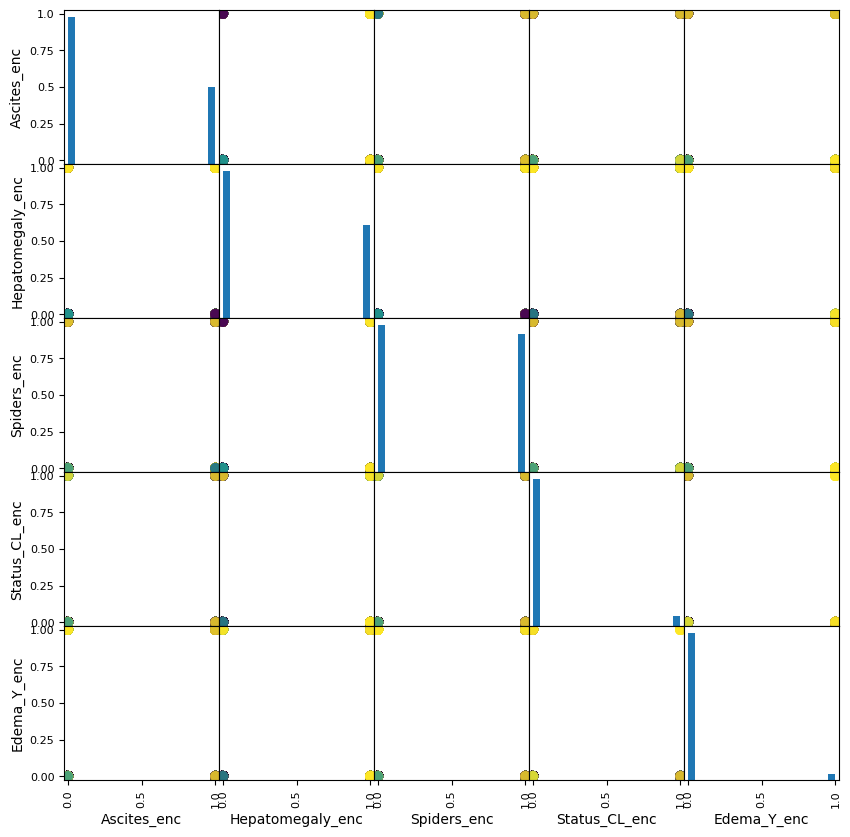

In [ ]:

liver_dataframe = pd.DataFrame(xtrain4, columns=xtrain4.columns)

pd.plotting.scatter_matrix(liver_dataframe, c=Y, figsize=(10, 10),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)


# Decision Tree Classification

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
print(X.shape)
print(y.shape)

(9639, 17)
(9639, 1)


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# feature scaling
m_scaler = MinMaxScaler()
X_train_scaled_m = m_scaler.fit_transform(X_train)
X_test_scaled_m = m_scaler.transform(X_test)

In [ ]:
# # feature scaling: Standard Scaling

# s_scaler = StandardScaler()
# X_train_scaled_s = s_scaler.fit_transform(X_train)
# X_test_scaled_s = s_scaler.transform(X_test)

In [ ]:
# model training for min max scaler
decisionTree_model = DecisionTreeClassifier(random_state=42)
decisionTree_model.fit(X_train_scaled_m, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
print(f"Test set accuracy for min max scaling: {decisionTree_model.score(X_test_scaled_m, y_test)}")

Test set accuracy for min max scaling: 0.7410096818810512


In [ ]:
# decisionTree_model.fit(X_train_scaled_s, y_train)

In [ ]:
# print(f"test set accuracy for standard scaling: {decisionTree_model.score(X_test_scaled_s, y_test)}")
# min max scaling works good here.

In [ ]:
# predict the test set
y_pred_dt = decisionTree_model.predict(X_test_scaled_m)

In [ ]:
# accuracy, classification report, and confusion matrix
accuracy = accuracy_score(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
class_report = classification_report(y_test, y_pred_dt)

In [ ]:
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.7410096818810512
Confusion Matrix:
[[663 191  69]
 [199 655 103]
 [ 78 109 825]]
Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.72      0.71       923
           2       0.69      0.68      0.69       957
           3       0.83      0.82      0.82      1012

    accuracy                           0.74      2892
   macro avg       0.74      0.74      0.74      2892
weighted avg       0.74      0.74      0.74      2892



# Gradient Boosting Classifier

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gradient_model = GradientBoostingClassifier(random_state=42)
gradient_model.fit(X_train_scaled_m, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier(random_state=42)

In [ ]:
print(f"Test set accuracy for min max scaling: {gradient_model.score(X_test_scaled_m, y_test)}")

Test set accuracy for min max scaling: 0.7883817427385892


In [ ]:
# # feature scaling: Standard Scaling

# s_scaler = StandardScaler()
# X_train_scaled_s = s_scaler.fit_transform(X_train)
# X_test_scaled_s = s_scaler.transform(X_test)

# gradient_model.fit(X_train_scaled_s, y_train)

# print(f"test set accuracy for standard scaling: {gradient_model.score(X_test_scaled_s, y_test)}")


In [ ]:
# predict the test set
y_pred_gc = gradient_model.predict(X_test_scaled_m)

In [ ]:
# accuracy, classification report, and confusion matrix
accuracy = accuracy_score(y_test, y_pred_gc)
conf_matrix = confusion_matrix(y_test, y_pred_gc)
class_report = classification_report(y_test, y_pred_gc)

In [ ]:
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.7883817427385892
Confusion Matrix:
[[690 186  47]
 [104 746 107]
 [ 64 104 844]]
Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.75      0.77       923
           2       0.72      0.78      0.75       957
           3       0.85      0.83      0.84      1012

    accuracy                           0.79      2892
   macro avg       0.79      0.79      0.79      2892
weighted avg       0.79      0.79      0.79      2892



# KNeigbhors Classifiers

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k_model = KNeighborsClassifier(n_neighbors=3)
k_model.fit(X_train_scaled_m, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
print(f"Test set accuracy for min max scaling: {k_model.score(X_test_scaled_m, y_test)}")

Test set accuracy for min max scaling: 0.710926694329184


In [ ]:
# # feature scaling: Standard Scaling

# s_scaler = StandardScaler()
# X_train_scaled_s = s_scaler.fit_transform(X_train)
# X_test_scaled_s = s_scaler.transform(X_test)

# k_model.fit(X_train_scaled_s, y_train)

# print(f"test set accuracy for standard scaling: {k_model.score(X_test_scaled_s, y_test)}")


In [ ]:
# predict the test set
y_pred_k = k_model.predict(X_test_scaled_m)

In [ ]:
# accuracy, classification report, and confusion matrix
accuracy = accuracy_score(y_test, y_pred_k)
conf_matrix = confusion_matrix(y_test, y_pred_k)
class_report = classification_report(y_test, y_pred_k)

In [ ]:
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.710926694329184
Confusion Matrix:
[[668 182  73]
 [224 617 116]
 [115 126 771]]
Classification Report:
              precision    recall  f1-score   support

           1       0.66      0.72      0.69       923
           2       0.67      0.64      0.66       957
           3       0.80      0.76      0.78      1012

    accuracy                           0.71      2892
   macro avg       0.71      0.71      0.71      2892
weighted avg       0.71      0.71      0.71      2892



# Model Selection/Comparison Analysis

<ipython-input-120-ed967e1d8aae>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


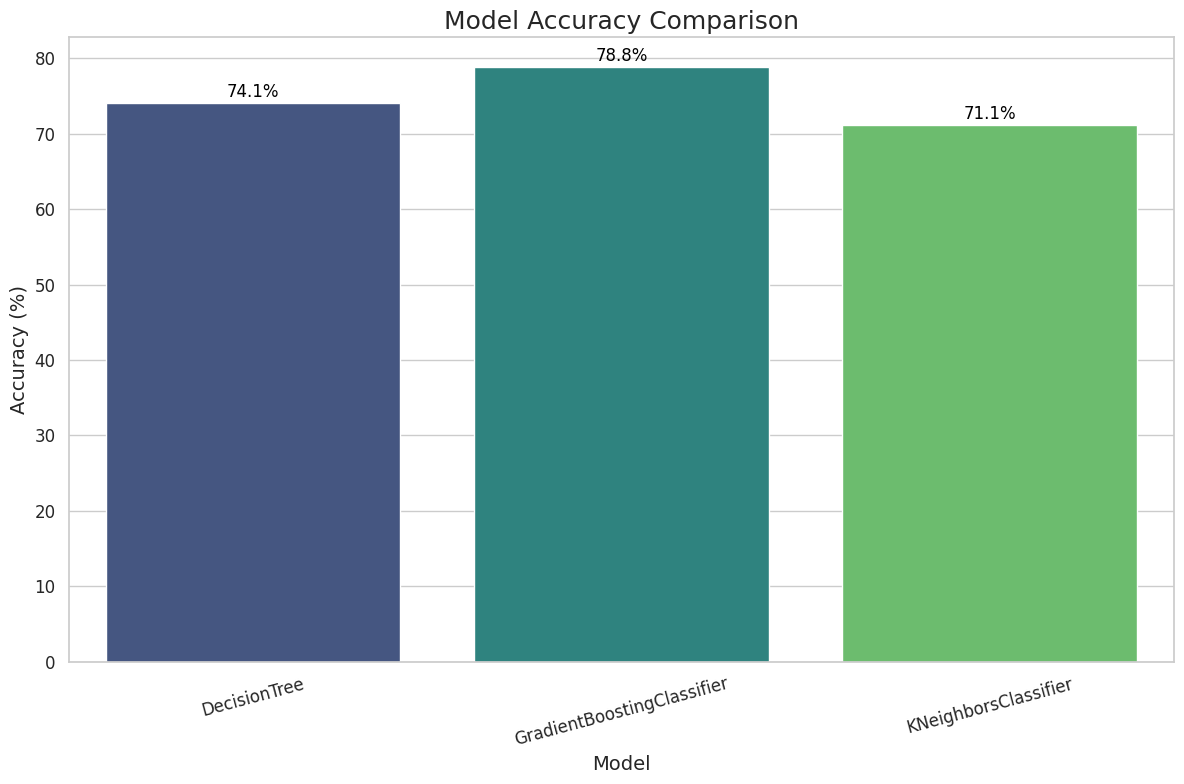

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ["DecisionTree", "GradientBoostingClassifier", "KNeighborsClassifier"]
accuracies = [0.7410096818810512*100, 0.7883817427385892*100, 0.710926694329184*100]


sns.set(style="whitegrid")


plt.figure(figsize=(12, 8))
sns.barplot(x=model_names, y=accuracies, palette="viridis")

# annotations to show accuracy values on the bars
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.3, f"{value:.1f}%", ha='center', va='bottom', fontsize=12, color='black')


plt.title("Model Accuracy Comparison", fontsize=18)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)


plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=12)


plt.tight_layout()
plt.show()


In [ ]:
# Here the Gradient Boosting Classifier works better than the other two models.